# Ablation: Model Architecture

Comparing different ViT architectures:
- **ViT-B/32**: Default architecture (OpenAI CLIP)
- **ViT-B/16**: Higher resolution patches
- **ViT-L/14**: Larger model capacity

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

In [8]:
# =============================================================================
# CONFIGURATION - Define ablation models
# =============================================================================

ABLATION_MODELS = {
    "ViT-B/32 (Default)": {
        "csv_path": "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv",
        "is_baseline": True,
        "description": "Default: ViT-B/32 from OpenAI CLIP"
    },
    "ViT-B/16": {
        "csv_path": "../evaluation/ablations/15-Jan_ablation_model_vit_b16_openai.csv",
        "is_baseline": False,
        "description": "Higher resolution: 16x16 patches"
    },
    "ViT-L/14": {
        "csv_path": "../evaluation/ablations/15-Jan_ablation_model_vit_l14_openai.csv",
        "is_baseline": False,
        "description": "Larger model: ViT-Large with 14x14 patches"
    },
}

# Primary metric for comparison
PRIMARY_METRIC = "text_contrastive_accuracy"

# Checkpoint selection (use best or specific step)
CHECKPOINT_STEP = None  # None = use best checkpoint, or specify step like 5000

print("Ablation: Model Architecture")
print("="*50)
for name, cfg in ABLATION_MODELS.items():
    baseline_mark = " [BASELINE]" if cfg["is_baseline"] else ""
    print(f"  {name}{baseline_mark}: {cfg['description']}")

Ablation: Model Architecture
  ViT-B/32 (Default) [BASELINE]: Default: ViT-B/32 from OpenAI CLIP
  ViT-B/16: Higher resolution: 16x16 patches
  ViT-L/14: Larger model: ViT-Large with 14x14 patches


In [3]:
# =============================================================================
# DATA LOADING FUNCTIONS
# =============================================================================

def load_ablation_csv(csv_path: str) -> pd.DataFrame:
    """Load and parse an ablation CSV file."""
    path = Path(csv_path)
    if not path.exists():
        print(f"WARNING: File not found: {path}")
        return pd.DataFrame()
    
    df = pd.read_csv(path)
    return df


def select_checkpoint(df: pd.DataFrame, metric: str = PRIMARY_METRIC, 
                      step: int = None) -> pd.DataFrame:
    """Select best checkpoint or specific step.
    
    If step is None, selects the checkpoint with highest average metric across datasets.
    """
    if df.empty:
        return df
    
    if step is not None:
        return df[df['step'] == step]
    
    # Find best checkpoint based on average metric
    metric_df = df[df['metric'] == metric].copy()
    if metric_df.empty:
        # Fallback to first available step
        return df[df['step'] == df['step'].iloc[0]]
    
    # Convert to numeric, coercing errors (handles JSON dict values)
    metric_df['value'] = pd.to_numeric(metric_df['value'], errors='coerce')
    metric_df = metric_df.dropna(subset=['value'])
    
    if metric_df.empty:
        return df[df['step'] == df['step'].iloc[0]]
    
    avg_by_step = metric_df.groupby('step')['value'].mean()
    best_step = avg_by_step.idxmax()
    
    return df[df['step'] == best_step]


def extract_dataset_scores(df: pd.DataFrame, metric: str = PRIMARY_METRIC) -> dict:
    """Extract per-dataset scores for a given metric."""
    metric_df = df[df['metric'] == metric].copy()
    
    # Convert to numeric, coercing errors (handles JSON dict values)
    metric_df['value'] = pd.to_numeric(metric_df['value'], errors='coerce')
    metric_df = metric_df.dropna(subset=['value'])
    
    scores = {}
    for _, row in metric_df.iterrows():
        dataset = row['dataset']
        subset = row.get('subset', 'all')
        key = f"{dataset}" if subset in ['all', ''] else f"{dataset}/{subset}"
        scores[key] = row['value']
    
    return scores


def load_all_ablation_models(models_config: dict, metric: str = PRIMARY_METRIC,
                             checkpoint_step: int = None) -> pd.DataFrame:
    """Load all ablation models and create a comparison table.
    
    Only includes datasets that are present in ALL models (intersection).
    """
    all_scores = {}
    
    for model_name, cfg in models_config.items():
        print(f"Loading {model_name}...")
        df = load_ablation_csv(cfg['csv_path'])
        
        if df.empty:
            print(f"  WARNING: No data for {model_name}")
            continue
        
        df_ckpt = select_checkpoint(df, metric=metric, step=checkpoint_step)
        scores = extract_dataset_scores(df_ckpt, metric=metric)
        
        step_used = df_ckpt['step'].iloc[0] if not df_ckpt.empty else 'N/A'
        print(f"  Loaded {len(scores)} datasets (step={step_used})")
        
        all_scores[model_name] = scores
    
    # Create DataFrame
    result = pd.DataFrame(all_scores).T
    result.index.name = 'Model'
    
    # Filter to common datasets (columns present in ALL models)
    common_cols = result.dropna(axis=1, how='any').columns.tolist()
    print(f"\nCommon datasets ({len(common_cols)}): {common_cols}")
    result = result[common_cols]
    
    return result


# Load all models
scores_df = load_all_ablation_models(ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP)
print(f"\nLoaded {len(scores_df)} models, {len(scores_df.columns)} datasets")

Loading ViT-B/32 (Default)...
  Loaded 55 datasets (step=15000)
Loading ViT-B/16...
  Loaded 55 datasets (step=20000)
Loading ViT-L/14...
  Loaded 55 datasets (step=35000)

Common datasets (55): ['VisMin', 'BLA/ap', 'SugarCrepe_PP/replace_attribute', 'SugarCrepe/swap_obj', 'ControlledImages/VG-Two', 'NegBench/msr_vtt_mcq_rephrased_llama', 'COLA/multi_objects', 'VALSE/existence', 'BLA/co', 'SugarCrepe_PP/replace_relation', 'VG_Attribution', 'COCO_Counterfactuals', 'NegBench/VOC2007_mcq_llama3.1_rephrased', 'SPEC_I2T/count', 'VALSE/plurals', 'BLA/rc', 'SugarCrepe/add_att', 'VG_Relation', 'Winoground', 'COCO_Order', 'SPEC_I2T/relative_spatial', 'VALSE/counting', 'SugarCrepe/add_obj', 'ControlledImages/A', 'NegBench/COCO_val_mcq_llama3.1_rephrased', 'Flickr30k_Order', 'SPEC_I2T/relative_size', 'VALSE/relations', 'ColorSwap', 'SugarCrepe/replace_att', 'ControlledImages/B', 'SPEC_I2T/absolute_size', 'VALSE/actions', 'SugarCrepe_PP/swap_object', 'SugarCrepe/replace_obj', 'ControlledImages/COC

In [4]:
# =============================================================================
# DISPLAY RAW SCORES TABLE
# =============================================================================

# Convert to percentage and display
scores_pct = scores_df * 100

# Add average column
scores_pct['Average'] = scores_pct.mean(axis=1)

print("\n" + "="*60)
print(f"ABLATION: MODEL ARCHITECTURE")
print(f"Metric: {PRIMARY_METRIC}")
print("="*60)
display(scores_pct.round(1).style.highlight_max(axis=0, color='lightgreen'))


ABLATION: MODEL ARCHITECTURE
Metric: text_contrastive_accuracy


,VisMin,BLA/ap,SugarCrepe_PP/replace_attribute,SugarCrepe/swap_obj,ControlledImages/VG-Two,NegBench/msr_vtt_mcq_rephrased_llama,COLA/multi_objects,VALSE/existence,BLA/co,SugarCrepe_PP/replace_relation,VG_Attribution,COCO_Counterfactuals,NegBench/VOC2007_mcq_llama3.1_rephrased,SPEC_I2T/count,VALSE/plurals,BLA/rc,SugarCrepe/add_att,VG_Relation,Winoground,COCO_Order,SPEC_I2T/relative_spatial,VALSE/counting,SugarCrepe/add_obj,ControlledImages/A,NegBench/COCO_val_mcq_llama3.1_rephrased,Flickr30k_Order,SPEC_I2T/relative_size,VALSE/relations,ColorSwap,SugarCrepe/replace_att,ControlledImages/B,SPEC_I2T/absolute_size,VALSE/actions,SugarCrepe_PP/swap_object,SugarCrepe/replace_obj,ControlledImages/COCO-One,SPEC_I2T/absolute_spatial,VALSE/coreference,SugarCrepe_PP/swap_atribute,SugarCrepe/replace_rel,ControlledImages/COCO-Two,SPEC_I2T/existence,VALSE/noun phrases,SugarCrepe_PP/replace_object,SugarCrepe/swap_att,ControlledImages/VG-One,MMVP/Camera Perspective,MMVP/Color,MMVP/Orientation,MMVP/Presence,MMVP/Quantity,MMVP/Spatial,MMVP/State,MMVP/Structural Character,MMVP/Text,Average
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ViT-B/32 (Default),78.600000,52.700000,74.200000,69.000000,53.100000,29.200000,41.000000,83.400000,48.400000,62.400000,70.000000,78.200000,37.800000,34.500000,70.500000,49.600000,80.800000,59.500000,29.800000,95.300000,29.500000,66.500000,90.800000,29.100000,31.400000,96.700000,32.700000,70.100000,59.000000,86.200000,34.600000,38.800000,83.200000,52.200000,94.900000,48.000000,12.200000,56.200000,56.500000,79.700000,50.900000,68.700000,93.700000,91.700000,74.500000,45.100000,6.700000,13.300000,13.300000,0.000000,6.700000,46.700000,13.300000,6.700000,13.300000,52.600000
ViT-B/16,78.500000,51.800000,79.100000,71.400000,48.800000,31.600000,44.300000,86.900000,48.300000,65.300000,70.100000,83.700000,33.500000,34.700000,73.600000,47.500000,84.800000,60.000000,28.200000,94.400000,27.200000,69.600000,93.900000,29.900000,28.200000,96.500000,26.600000,71.600000,61.000000,89.800000,31.400000,38.700000,85.700000,50.200000,96.300000,43.400000,12.200000,55.200000,55.600000,81.100000,52.500000,68.900000,95.500000,94.200000,77.500000,47.300000,0.000000,13.300000,0.000000,0.000000,20.000000,40.000000,0.000000,6.700000,6.700000,52.400000
ViT-L/14,78.900000,59.000000,81.100000,73.900000,49.600000,31.900000,42.900000,86.500000,48.200000,68.100000,70.700000,87.800000,41.700000,40.200000,71.200000,49.300000,88.300000,60.500000,28.200000,96.100000,28.200000,74.900000,95.200000,31.600000,30.800000,97.200000,27.600000,76.100000,64.700000,90.500000,25.000000,42.200000,87.200000,48.200000,97.800000,49.200000,11.800000,60.000000,55.700000,84.100000,56.100000,70.400000,97.600000,95.600000,77.600000,44.100000,0.000000,13.300000,20.000000,13.300000,20.000000,6.700000,20.000000,0.000000,6.700000,54.100000


In [6]:
# =============================================================================
# LOAD ALL METRICS (Text, Image, Group Contrastive Accuracy)
# =============================================================================

METRICS = ["text_contrastive_accuracy", "image_contrastive_accuracy", "group_contrastive_accuracy"]
METRIC_DISPLAY = {
    "text_contrastive_accuracy": "I2T",
    "image_contrastive_accuracy": "T2I", 
    "group_contrastive_accuracy": "Group"
}

def load_all_metrics_for_model(csv_path: str, metrics: list, checkpoint_step: int = None) -> dict:
    """Load all metrics for a model, returning per-dataset and overall averages."""
    df = load_ablation_csv(csv_path)
    if df.empty:
        return {}
    
    # Select checkpoint based on primary metric
    df_ckpt = select_checkpoint(df, metric=PRIMARY_METRIC, step=checkpoint_step)
    
    result = {}
    for metric in metrics:
        metric_df = df_ckpt[df_ckpt['metric'] == metric].copy()
        metric_df['value'] = pd.to_numeric(metric_df['value'], errors='coerce')
        metric_df = metric_df.dropna(subset=['value'])
        
        if metric_df.empty:
            continue
            
        # Per-dataset scores (average over subsets)
        dataset_scores = metric_df.groupby('dataset')['value'].mean().to_dict()
        
        # Overall average
        overall_avg = metric_df['value'].mean()
        
        result[metric] = {
            'per_dataset': dataset_scores,
            'average': overall_avg
        }
    
    return result


def load_all_models_all_metrics(models_config: dict, metrics: list, 
                                 checkpoint_step: int = None) -> pd.DataFrame:
    """Load all models with all metrics, create a summary table.
    
    Only includes datasets that are present in ALL models (intersection).
    """
    # First pass: collect all data and find common datasets
    all_model_data = {}
    all_datasets_per_model = {}
    
    for model_name, cfg in models_config.items():
        print(f"Loading {model_name}...")
        model_data = load_all_metrics_for_model(cfg['csv_path'], metrics, checkpoint_step)
        
        if not model_data:
            print(f"  WARNING: No data")
            continue
        
        all_model_data[model_name] = model_data
        
        # Collect datasets for this model (from primary metric)
        primary_metric = metrics[0]
        if primary_metric in model_data:
            all_datasets_per_model[model_name] = set(model_data[primary_metric]['per_dataset'].keys())
        
        print(f"  Loaded metrics: {[METRIC_DISPLAY[m] for m in model_data.keys()]}")
    
    # Find common datasets across ALL models
    if all_datasets_per_model:
        common_datasets = set.intersection(*all_datasets_per_model.values())
        print(f"\nCommon datasets across all models ({len(common_datasets)}): {sorted(common_datasets)}")
    else:
        common_datasets = set()
    
    # Second pass: build records using only common datasets
    records = []
    for model_name, cfg in models_config.items():
        if model_name not in all_model_data:
            continue
        
        model_data = all_model_data[model_name]
        record = {'Model': model_name, 'is_baseline': cfg.get('is_baseline', False)}
        
        for metric in metrics:
            if metric not in model_data:
                continue
            
            # Filter to common datasets only
            filtered_scores = {ds: val for ds, val in model_data[metric]['per_dataset'].items() 
                               if ds in common_datasets}
            
            # Compute average over common datasets only
            if filtered_scores:
                record[METRIC_DISPLAY[metric]] = np.mean(list(filtered_scores.values()))
                
                # Also store per-dataset for later
                for ds, val in filtered_scores.items():
                    record[f"{ds}_{METRIC_DISPLAY[metric]}"] = val
        
        records.append(record)
    
    return pd.DataFrame(records).set_index('Model')


# Load all models with all metrics
all_metrics_df = load_all_models_all_metrics(ABLATION_MODELS, METRICS, CHECKPOINT_STEP)

# Extract just the summary columns (I2T, T2I, Group)
summary_cols = [col for col in ['I2T', 'T2I', 'Group'] if col in all_metrics_df.columns]
summary_df = all_metrics_df[summary_cols].copy()

# Add overall average
summary_df['Average'] = summary_df.mean(axis=1)

print("\n" + "="*60)
print("ABLATION: MODEL ARCHITECTURE - ALL METRICS")
print("="*60)
display((summary_df * 100).round(1).style.highlight_max(axis=0, color='lightgreen'))

Loading ViT-B/32 (Default)...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading ViT-B/16...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading ViT-L/14...
  Loaded metrics: ['I2T', 'T2I', 'Group']

Common datasets across all models (17): ['BLA', 'COCO_Counterfactuals', 'COCO_Order', 'COLA', 'ColorSwap', 'ControlledImages', 'Flickr30k_Order', 'MMVP', 'NegBench', 'SPEC_I2T', 'SugarCrepe', 'SugarCrepe_PP', 'VALSE', 'VG_Attribution', 'VG_Relation', 'VisMin', 'Winoground']

ABLATION: MODEL ARCHITECTURE - ALL METRICS


,I2T,T2I,Group,Average
Model,,,,
ViT-B/32 (Default),59.300000,41.600000,25.400000,42.100000
ViT-B/16,59.700000,42.000000,26.000000,42.600000
ViT-L/14,61.200000,45.200000,29.300000,45.200000


In [11]:
# =============================================================================
# LATEX TABLE GENERATION
# =============================================================================

def make_latex_ablation_table(
    df: pd.DataFrame,
    models_config: dict,
    caption: str = "Ablation study results.",
    label: str = "tab:ablation",
    decimals: int = 1,
    font_size: str = "small",
):
    """
    Generate a LaTeX table for ablation study.
    
    Args:
        df: DataFrame with Model as index, metrics as columns (values in [0,1])
        models_config: Dict with model configs (for is_baseline flag)
        caption: Table caption
        label: Table label
        decimals: Decimal places for formatting
        font_size: LaTeX font size command
    """
    
    def fmt(v):
        if pd.isna(v):
            return "--"
        return f"{v * 100:.{decimals}f}"
    
    def latex_escape(s):
        return s.replace("_", r"\_").replace("%", r"\%").replace("&", r"\&")
    
    # Find baseline and best per column
    baseline_model = [name for name, cfg in models_config.items() if cfg.get('is_baseline', False)]
    baseline_model = baseline_model[0] if baseline_model else None
    
    best_per_col = {col: df[col].idxmax() for col in df.columns}
    
    # Build table
    cols = list(df.columns)
    col_spec = "l" + "c" * len(cols)
    
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"  \centering")
    lines.append(rf"  \{font_size}")
    lines.append(f"  \\caption{{{caption}}}")
    lines.append(f"  \\label{{{label}}}")
    lines.append(rf"  \begin{{tabular}}{{{col_spec}}}")
    lines.append(r"    \toprule")
    
    # Header
    header = ["Model"] + [latex_escape(c) for c in cols]
    lines.append("    " + " & ".join(header) + r" \\")
    lines.append(r"    \midrule")
    
    # Body
    for model in df.index:
        row = [latex_escape(model)]
        
        for col in cols:
            val = fmt(df.loc[model, col])
            
            # Style: bold for best, underline for baseline
            is_best = (model == best_per_col[col])
            is_baseline = (model == baseline_model)
            
            if is_baseline:
                val = r"\underline{" + val + "}"
            if is_best:
                val = r"\textbf{" + val + "}"
            
            row.append(val)
        
        lines.append("    " + " & ".join(row) + r" \\")
    
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)


# Generate LaTeX table
latex_table = make_latex_ablation_table(
    summary_df,
    ABLATION_MODELS,
    caption="Architecture ablation. I2T = Image-to-Text (text contrastive), T2I = Text-to-Image (image contrastive), Group = both correct. Best in \\textbf{bold}, baseline \\underline{underlined}.",
    label="tab:ablation_architecture",
)

print("="*60)
print("LATEX TABLE")
print("="*60)
print(latex_table)

LATEX TABLE
\begin{table}[t]
  \centering
  \small
  \caption{Architecture ablation. I2T = Image-to-Text (text contrastive), T2I = Text-to-Image (image contrastive), Group = both correct. Best in \textbf{bold}, baseline \underline{underlined}.}
  \label{tab:ablation_architecture}
  \begin{tabular}{lcccc}
    \toprule
    Model & I2T & T2I & Group & Average \\
    \midrule
    ViT-B/32 (Default) & \underline{59.3} & \underline{41.6} & \underline{25.4} & \underline{42.1} \\
    ViT-B/16 & 59.7 & 42.0 & 26.0 & 42.6 \\
    ViT-L/14 & \textbf{61.2} & \textbf{45.2} & \textbf{29.3} & \textbf{45.2} \\
    \bottomrule
  \end{tabular}
\end{table}


In [12]:
# =============================================================================
# COMPUTE DELTAS FROM BASELINE
# =============================================================================

# Find baseline model
baseline_model = [name for name, cfg in ABLATION_MODELS.items() if cfg['is_baseline']][0]
print(f"Baseline model: {baseline_model}")

# Compute deltas
baseline_scores = scores_pct.loc[baseline_model]
deltas_df = scores_pct.sub(baseline_scores, axis=1)

print("\n" + "="*60)
print("DELTA FROM BASELINE (percentage points)")
print("="*60)
display(deltas_df.round(2).style.background_gradient(cmap='RdYlGn', axis=None))

Baseline model: ViT-B/32 (Default)

DELTA FROM BASELINE (percentage points)


,VisMin,BLA/ap,SugarCrepe_PP/replace_attribute,SugarCrepe/swap_obj,ControlledImages/VG-Two,NegBench/msr_vtt_mcq_rephrased_llama,COLA/multi_objects,VALSE/existence,BLA/co,SugarCrepe_PP/replace_relation,VG_Attribution,COCO_Counterfactuals,NegBench/VOC2007_mcq_llama3.1_rephrased,SPEC_I2T/count,VALSE/plurals,BLA/rc,SugarCrepe/add_att,VG_Relation,Winoground,COCO_Order,SPEC_I2T/relative_spatial,VALSE/counting,SugarCrepe/add_obj,ControlledImages/A,NegBench/COCO_val_mcq_llama3.1_rephrased,Flickr30k_Order,SPEC_I2T/relative_size,VALSE/relations,ColorSwap,SugarCrepe/replace_att,ControlledImages/B,SPEC_I2T/absolute_size,VALSE/actions,SugarCrepe_PP/swap_object,SugarCrepe/replace_obj,ControlledImages/COCO-One,SPEC_I2T/absolute_spatial,VALSE/coreference,SugarCrepe_PP/swap_atribute,SugarCrepe/replace_rel,ControlledImages/COCO-Two,SPEC_I2T/existence,VALSE/noun phrases,SugarCrepe_PP/replace_object,SugarCrepe/swap_att,ControlledImages/VG-One,MMVP/Camera Perspective,MMVP/Color,MMVP/Orientation,MMVP/Presence,MMVP/Quantity,MMVP/Spatial,MMVP/State,MMVP/Structural Character,MMVP/Text,Average
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ViT-B/32 (Default),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ViT-B/16,-0.190000,-0.900000,4.820000,2.450000,-4.260000,2.400000,3.330000,3.560000,-0.080000,2.840000,0.090000,5.500000,-4.290000,0.200000,3.060000,-2.010000,4.050000,0.500000,-1.500000,-0.950000,-2.300000,3.130000,3.100000,0.730000,-3.230000,-0.220000,-6.070000,1.500000,2.000000,3.680000,-3.190000,-0.130000,2.440000,-2.040000,1.450000,-4.540000,0.000000,-0.990000,-0.900000,1.420000,1.590000,0.200000,1.800000,2.480000,3.000000,2.210000,-6.670000,0.000000,-13.330000,0.000000,13.330000,-6.670000,-13.330000,0.000000,-6.670000,-0.140000
ViT-L/14,0.240000,6.280000,6.850000,4.900000,-3.490000,2.700000,1.900000,3.170000,-0.150000,5.690000,0.660000,9.590000,3.880000,5.780000,0.710000,-0.300000,7.510000,0.970000,-1.500000,0.800000,-1.250000,8.380000,4.360000,2.430000,-0.680000,0.460000,-5.070000,5.980000,5.670000,4.310000,-9.560000,3.400000,3.940000,-4.080000,2.910000,1.250000,-0.400000,3.820000,-0.750000,4.480000,5.230000,1.700000,3.820000,3.930000,3.150000,-0.930000,-6.670000,0.000000,6.670000,13.330000,13.330000,-40.000000,6.670000,-6.670000,-6.670000,1.500000


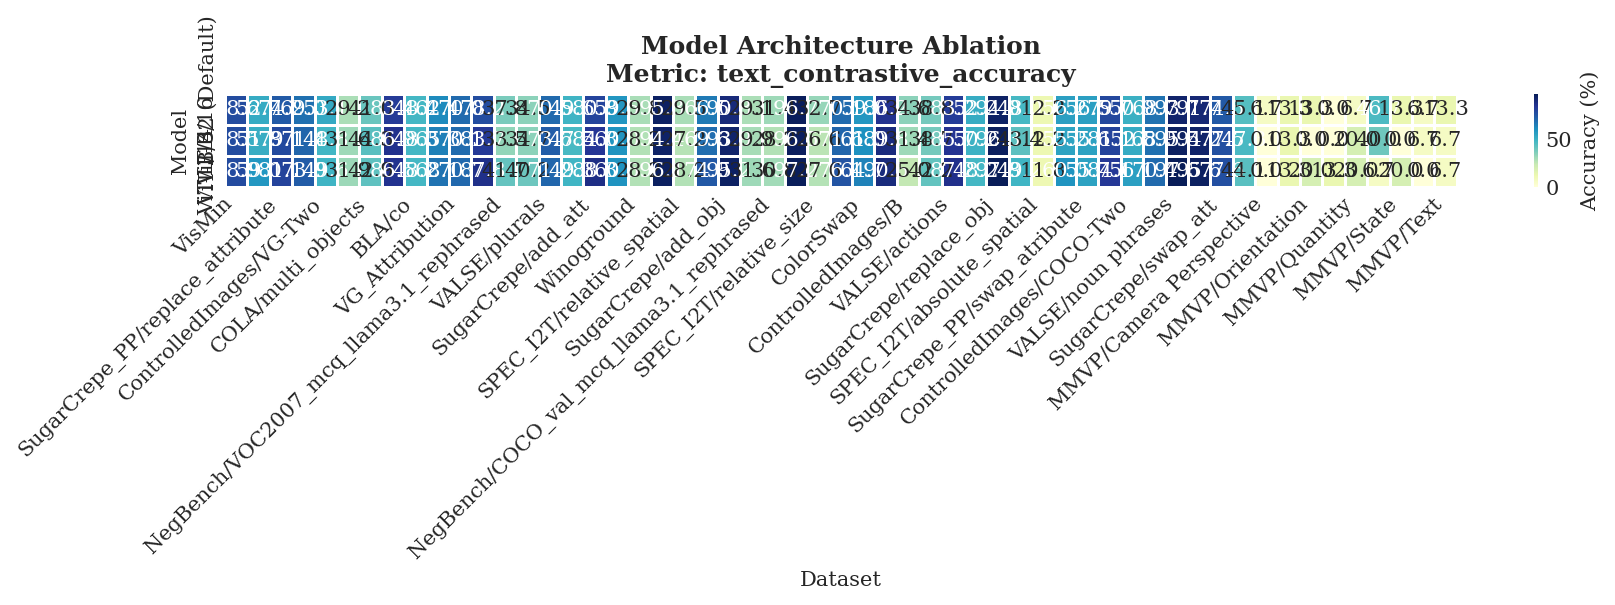

Saved: ../paper_figures/ablation_architecture_heatmap.pdf


In [13]:
# =============================================================================
# VISUALIZATION: HEATMAP
# =============================================================================

# Remove 'Average' for heatmap (we'll show it separately)
plot_df = scores_pct.drop(columns=['Average'], errors='ignore')

fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(plot_df, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Accuracy (%)'})

ax.set_title(f'Model Architecture Ablation\nMetric: {PRIMARY_METRIC}', fontsize=12, fontweight='bold')
ax.set_xlabel('Dataset', fontsize=10)
ax.set_ylabel('Model', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save
Path('../paper_figures').mkdir(exist_ok=True)
plt.savefig('../paper_figures/ablation_architecture_heatmap.pdf', bbox_inches='tight', dpi=300)
plt.show()

print("Saved: ../paper_figures/ablation_architecture_heatmap.pdf")

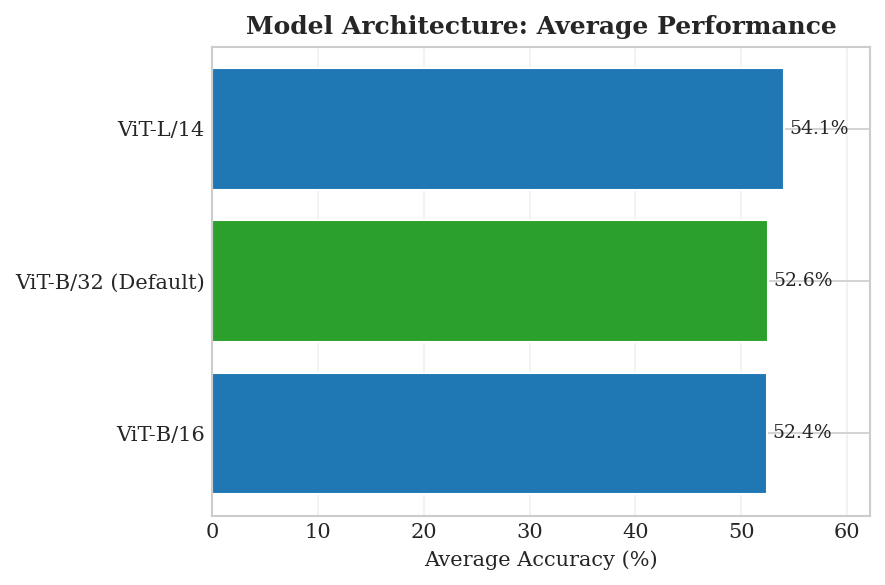

Saved: ../paper_figures/ablation_architecture_bar.pdf


In [14]:
# =============================================================================
# VISUALIZATION: BAR CHART (Average Performance)
# =============================================================================

# Average scores
avg_scores = scores_pct['Average'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))

colors = ['#2ca02c' if name == baseline_model else '#1f77b4' for name in avg_scores.index]
bars = ax.barh(range(len(avg_scores)), avg_scores.values, color=colors, edgecolor='white')

ax.set_yticks(range(len(avg_scores)))
ax.set_yticklabels(avg_scores.index)
ax.set_xlabel('Average Accuracy (%)')
ax.set_title('Model Architecture: Average Performance', fontweight='bold')
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, avg_scores.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlim(0, avg_scores.max() * 1.15)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../paper_figures/ablation_architecture_bar.pdf', bbox_inches='tight', dpi=300)
plt.show()

print("Saved: ../paper_figures/ablation_architecture_bar.pdf")

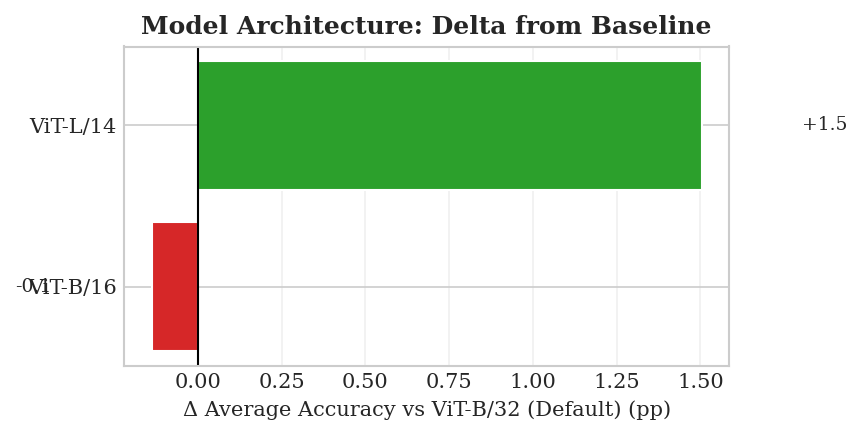

Saved: ../paper_figures/ablation_architecture_delta.pdf


In [15]:
# =============================================================================
# VISUALIZATION: DELTA BAR CHART
# =============================================================================

# Delta from baseline (average)
avg_deltas = deltas_df['Average'].drop(baseline_model).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))

colors = ['#2ca02c' if d >= 0 else '#d62728' for d in avg_deltas.values]
bars = ax.barh(range(len(avg_deltas)), avg_deltas.values, color=colors, edgecolor='white')

ax.axvline(x=0, color='black', linewidth=1)
ax.set_yticks(range(len(avg_deltas)))
ax.set_yticklabels(avg_deltas.index)
ax.set_xlabel(f'Δ Average Accuracy vs {baseline_model} (pp)')
ax.set_title('Model Architecture: Delta from Baseline', fontweight='bold')
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, avg_deltas.values):
    offset = 0.3 if val >= 0 else -0.3
    ha = 'left' if val >= 0 else 'right'
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}', va='center', ha=ha, fontsize=9)

ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../paper_figures/ablation_architecture_delta.pdf', bbox_inches='tight', dpi=300)
plt.show()

print("Saved: ../paper_figures/ablation_architecture_delta.pdf")

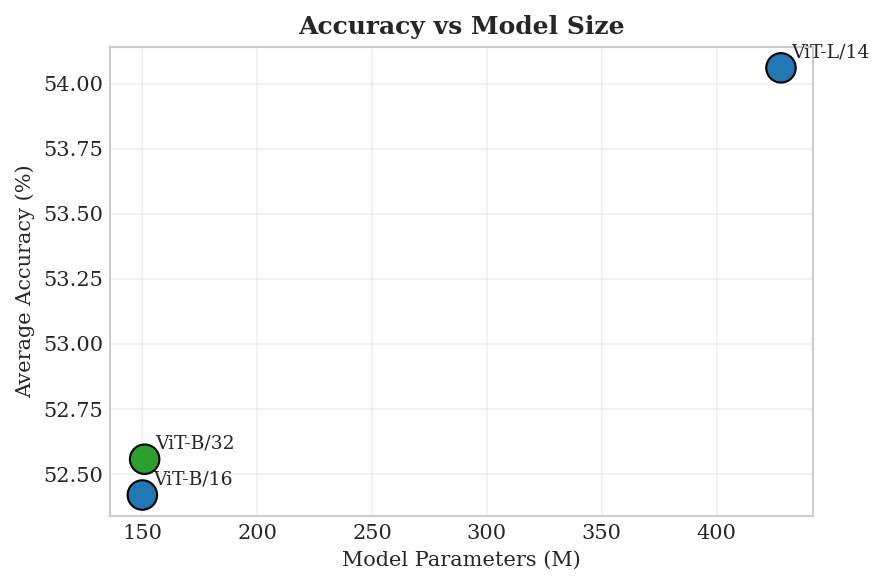

Saved: ../paper_figures/ablation_architecture_size.pdf


In [16]:
# =============================================================================
# MODEL SIZE COMPARISON
# =============================================================================

# Model parameters (approximate)
MODEL_PARAMS = {
    "ViT-B/32 (Default)": 151,  # ~151M params
    "ViT-B/16": 150,            # ~150M params (same as B/32)
    "ViT-L/14": 428,            # ~428M params
}

fig, ax = plt.subplots(figsize=(6, 4))

models_for_scatter = [m for m in avg_scores.index if m in MODEL_PARAMS]
params = [MODEL_PARAMS[m] for m in models_for_scatter]
accs = [avg_scores[m] for m in models_for_scatter]

colors = ['#2ca02c' if m == baseline_model else '#1f77b4' for m in models_for_scatter]

ax.scatter(params, accs, s=200, c=colors, edgecolors='black', linewidth=1, zorder=5)

for m, p, a in zip(models_for_scatter, params, accs):
    ax.annotate(m.replace(' (Default)', ''), (p, a), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel('Model Parameters (M)', fontsize=10)
ax.set_ylabel('Average Accuracy (%)', fontsize=10)
ax.set_title('Accuracy vs Model Size', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../paper_figures/ablation_architecture_size.pdf', bbox_inches='tight', dpi=300)
plt.show()

print("Saved: ../paper_figures/ablation_architecture_size.pdf")

In [17]:
# =============================================================================
# SUMMARY
# =============================================================================

print("\n" + "="*60)
print("SUMMARY: MODEL ARCHITECTURE ABLATION")
print("="*60)

print(f"\nBaseline: {baseline_model}")
print(f"Metric: {PRIMARY_METRIC}")

print(f"\nAverage Performance:")
for model in avg_scores.index:
    score = avg_scores[model]
    delta = deltas_df.loc[model, 'Average']
    params = MODEL_PARAMS.get(model, 'N/A')
    marker = "★" if model == baseline_model else " "
    print(f"  {marker} {model}: {score:.1f}% ({delta:+.1f}pp vs baseline) | {params}M params")

print(f"\nKey Findings:")
best_model = avg_scores.index[0]
worst_model = avg_scores.index[-1]
print(f"  - Best: {best_model} ({avg_scores[best_model]:.1f}%)")
print(f"  - Worst: {worst_model} ({avg_scores[worst_model]:.1f}%)")
print(f"  - Gap: {avg_scores[best_model] - avg_scores[worst_model]:.1f}pp")


SUMMARY: MODEL ARCHITECTURE ABLATION

Baseline: ViT-B/32 (Default)
Metric: text_contrastive_accuracy

Average Performance:
    ViT-L/14: 54.1% (+1.5pp vs baseline) | 428M params
  ★ ViT-B/32 (Default): 52.6% (+0.0pp vs baseline) | 151M params
    ViT-B/16: 52.4% (-0.1pp vs baseline) | 150M params

Key Findings:
  - Best: ViT-L/14 (54.1%)
  - Worst: ViT-B/16 (52.4%)
  - Gap: 1.6pp


In [ ]:
# =============================================================================
# DATASET-WISE AND SUBSET-WISE TABLES (with ARO merging)
# =============================================================================

from ablation_utils import (
    load_all_models_per_dataset,
    load_all_models_per_subset,
    make_latex_dataset_table,
    get_datasets_and_subsets,
    display_all_tables,
    load_benchmark_config
)

# Load benchmark config for dataset merge rules (e.g., ARO)
bench_cfg = load_benchmark_config()

# Display all tables for the primary metric (I2T) with ARO merging
dataset_df, subset_df, datasets_subsets = display_all_tables(
    ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP, 
    show_latex=True, apply_merge=True, benchmark_config=bench_cfg
)